In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, json

DRIVE_DIR_2 = '/content/drive/MyDrive/266-pipeline-tag-prediction'

Mounted at /content/drive


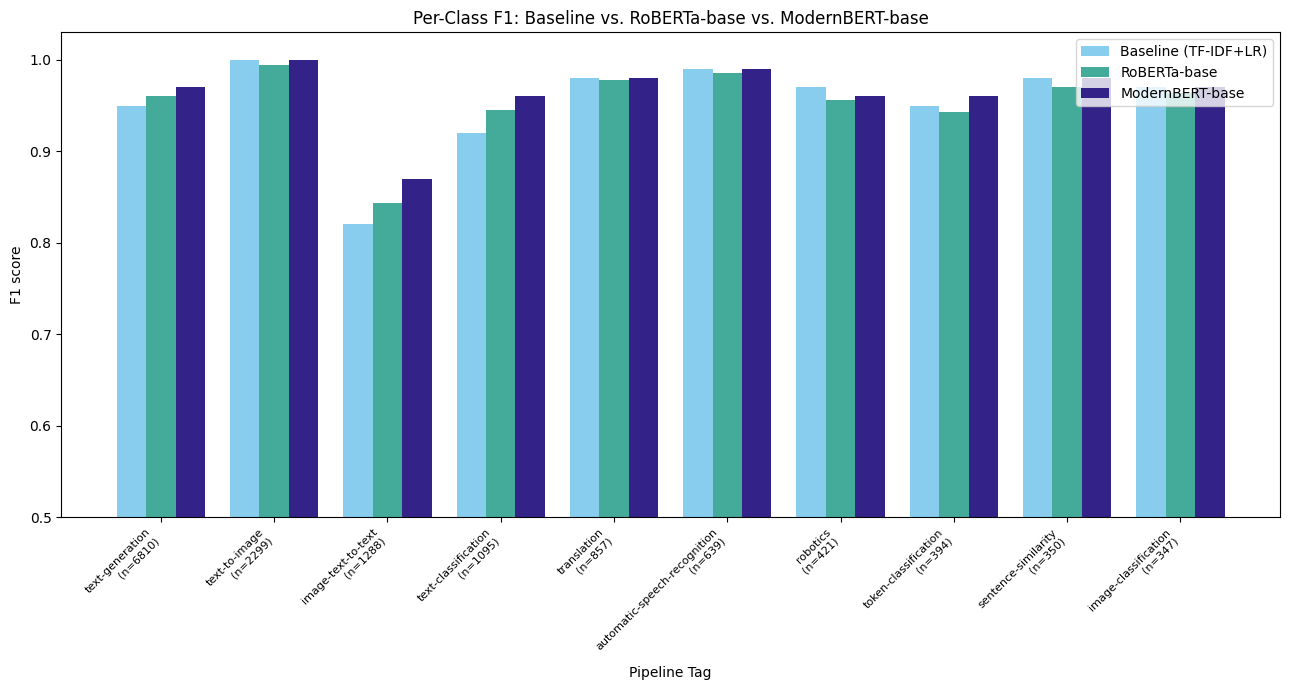

In [3]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np


classes = ["text-generation", "text-to-image", "image-text-to-text", "text-classification",
           "translation", "automatic-speech-recognition", "robotics", "sentence-similarity",
           "image-classification", "token-classification"]

# from classification reports
support = [6810, 2299, 1288, 1095, 857, 639, 421, 350, 347, 394]
baseline_f1  = [0.95, 1.00, 0.82, 0.92, 0.98, 0.99, 0.97, 0.98, 0.97, 0.95]
roberta_f1   = [0.9605, 0.9939, 0.8437, 0.9447, 0.9778, 0.9851, 0.9557, 0.9699, 0.9637, 0.9428]
modernbert_f1 = [0.97, 1.00, 0.87, 0.96, 0.98, 0.99, 0.96, 0.98, 0.97, 0.96]

# class size largest to smallest order
order = np.argsort(support)[::-1]
classes = [classes[i] for i in order]
support = [support[i] for i in order]
baseline_f1 = [baseline_f1[i] for i in order]
roberta_f1 = [roberta_f1[i] for i in order]
modernbert_f1 = [modernbert_f1[i] for i in order]

fig, ax = plt.subplots(figsize=(13, 7))
x = np.arange(len(classes))
width = 0.26

ax.bar(x - width, baseline_f1, width, label="Baseline (TF-IDF+LR)", color="#88CCEE")
ax.bar(x, roberta_f1, width, label="RoBERTa-base", color="#44AA99")
ax.bar(x + width,  modernbert_f1, width, label="ModernBERT-base", color="#332288")

labels = [f"{c}\n(n={s})" for c, s in zip(classes, support)]
ax.set_xticks(x)
ax.set_xlabel("Pipeline Tag")
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("F1 score")
ax.set_ylim(0.5, 1.03)
ax.set_title("Per-Class F1: Baseline vs. RoBERTa-base vs. ModernBERT-base")
ax.legend()
plt.tight_layout()

fig.savefig(f'{DRIVE_DIR_2}/all_model_f1_by_support.png', dpi=150, bbox_inches="tight")
plt.show()
